In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

In [3]:
ecommerece_data = pd.read_csv("../../../Datasets/shop_smart_ecommerce.csv")

In [6]:
ecommerece_data.head()
ecommerece_data.info()
ecommerece_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

(12330, 18)

In [7]:
ecommerece_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

ecommerece_data["Month"] = le.fit_transform(ecommerece_data["Month"])

In [ ]:
ecommerece_data["VisitorType"] = le.fit_transform(ecommerece_data["VisitorType"])

In [11]:
ecommerece_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,False


In [ ]:
X_columns = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month",
    "Region",
    "TrafficType",
    "VisitorType",
]

In [30]:
X = ecommerece_data.drop(columns=["Revenue"])
y = ecommerece_data["Revenue"]

In [15]:
X.head()
y.head()

0    False
1    False
2    False
3    False
4    False
Name: Revenue, dtype: bool

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

In [32]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

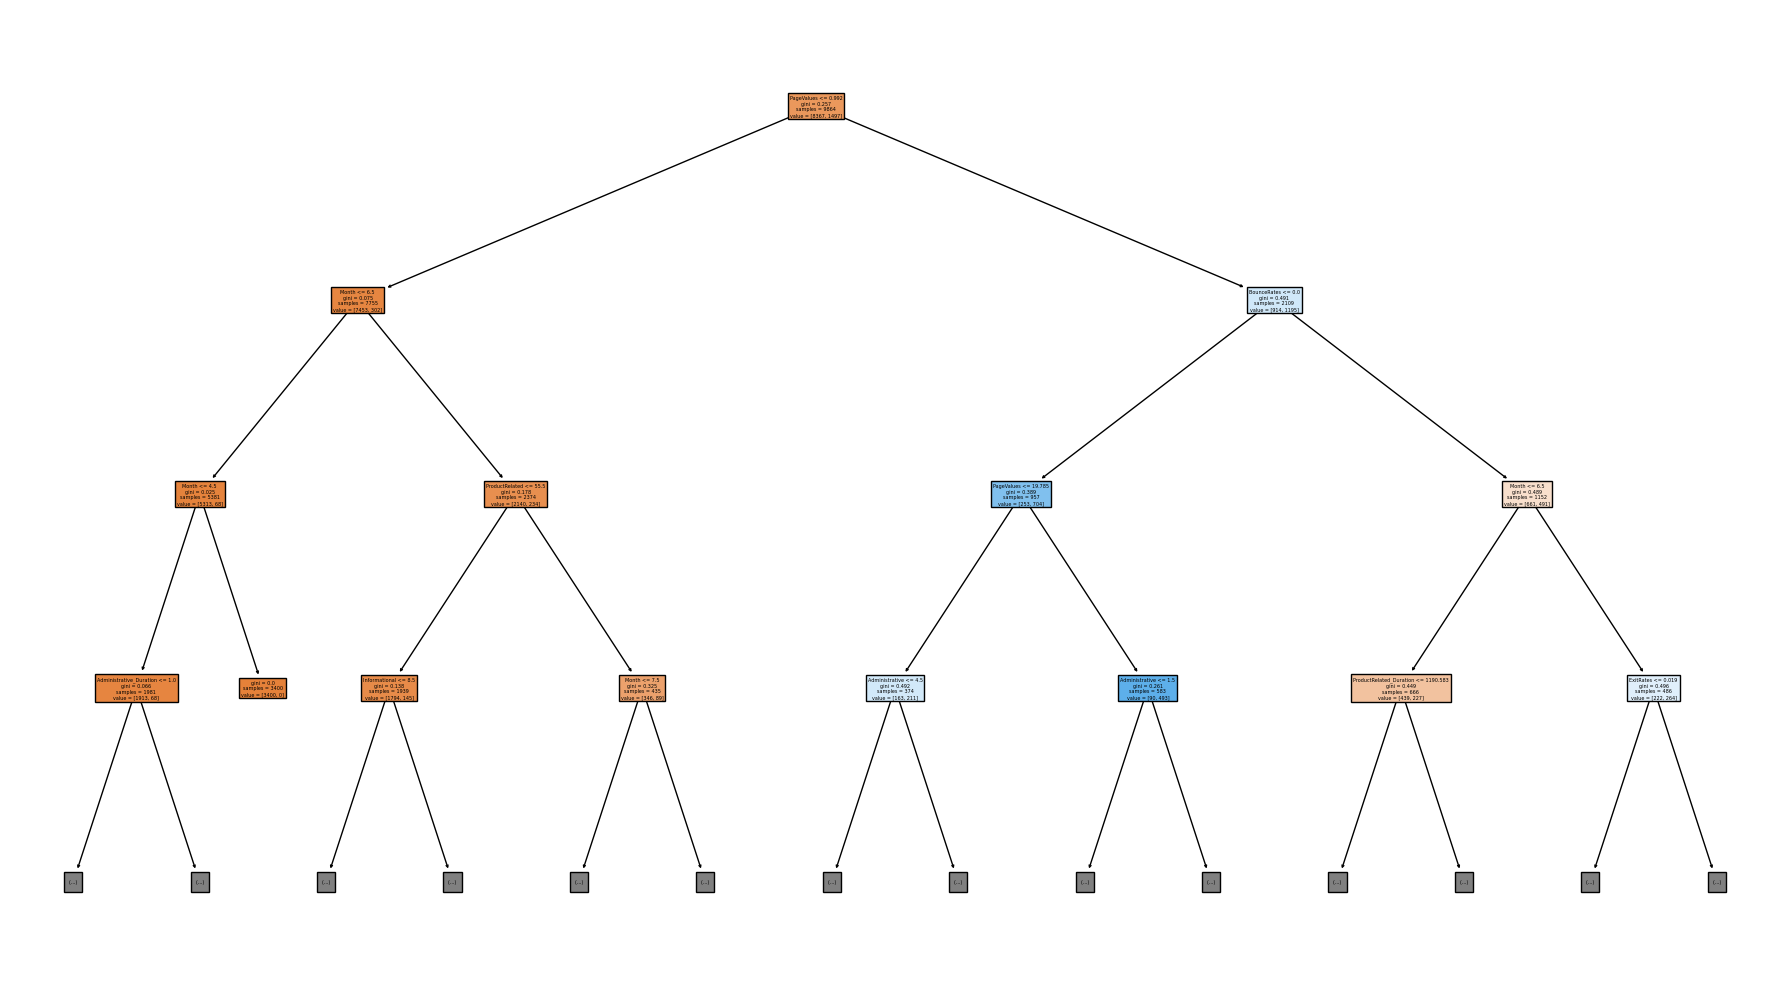

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(model, feature_names=X.columns, filled=True, max_depth=3)
plt.tight_layout()
plt.show()

In [34]:
y_pred = model.predict(X_test)
y_pred

array([False,  True,  True, ..., False, False, False])

In [35]:
from sklearn.metrics import f1_score

print("F1_Score : ", f1_score(y_test, y_pred))

F1_Score :  0.5850673194614443


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [37]:
df = pd.read_csv("../../../Datasets/shop_smart_ecommerce.csv")
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

In [38]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=30, class_weight="balanced", random_state=42
)

In [ ]:
pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", dt)])

In [43]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=30,
                                        random_state=42))])

In [44]:
y_pred = pipe.predict(X_test)

print("F1_score", f1_score(y_pred, y_test))
print("\nclassification_report\n", classification_report(y_pred, y_test))
print("\nConfusion Matrix\n", confusion_matrix(y_pred, y_test))

F1_score 0.6278381046396841

classification_report
               precision    recall  f1-score   support

           0       0.85      0.97      0.90      1835
           1       0.83      0.50      0.63       631

    accuracy                           0.85      2466
   macro avg       0.84      0.73      0.77      2466
weighted avg       0.85      0.85      0.83      2466


Confusion Matrix
 [[1771   64]
 [ 313  318]]


## Hyperparameter Tuning


In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {"model__max_depth": [4, 6, 8], "model__min_samples_leaf": [20, 30, 60]}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv = 5,
    n_jobs=1
)
grid.fit(X_train, y_train)
print("Best F1: ", grid.best_score_)
print("Best Params : " ,grid.best_params_)

Best F1:  0.6361893160071491
Best Params :  {'model__max_depth': 4, 'model__min_samples_leaf': 60}
